In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm


def plot_fpc_at_point(lon, lat, out_file="fpc_stackplot.png"):

    base_path = "/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years"

    # --- load datasets ---
    def load(path):
        return xr.open_dataset(path).FPC.sel(
            lon=lon, lat=lat, method="nearest"
        ).convert_calendar("standard").sel(time=slice("1970", "1979"))[:, 1:9]

    datasets = {
        "Baseline": load(f"{base_path}/baseline/output/fpc.nc"),
        "MM": load(f"{base_path}/MM/output/fpc.nc"),
        "DM": load(f"{base_path}/DM/output/fpc.nc"),
    }

    # adjust pft indexing
    for k in datasets:
        datasets[k]["pft"] = datasets[k].pft - 2

    # --- PFT names ---
    pft_names = [
        'tropical broadleaved evergreen tree',
        'tropical broadleaved raingreen tree',
        'temperate needleleaved evergreen tree',
        'temperate broadleaved evergreen tree',
        'temperate broadleaved summergreen tree',
        'boreal needleleaved evergreen tree',
        'boreal broadleaved summergreen tree',
        'boreal needleleaved summergreen tree'
        # 'Tropical C4 grass',
        # 'Temperate C3 grass',
        # 'Polar C3 grass'
    ]

    all_pfts = datasets["Baseline"].pft.values
    pft_labels = {p: pft_names[int(p)] for p in all_pfts}

    # --- colors ---
    tropical = [0, 1]
    temperate = [2, 3, 4]
    boreal = [5, 6, 7]
    # grass = [8, 9, 10]

    pft_colors = {}

    greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
    oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
    blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
    # purples = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

    for i, p in enumerate(tropical):
        pft_colors[p] = greens[i]
    for i, p in enumerate(temperate):
        pft_colors[p] = oranges[i]
    for i, p in enumerate(boreal):
        pft_colors[p] = blues[i]
    # for i, p in enumerate(grass):
    #     pft_colors[p] = purples[i]

    # --- plot ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    for ax, (name, data) in zip(axes, datasets.items()):

        time = pd.to_datetime(data.time.values)

        stack_data = [
            data.sel(pft=pft).values for pft in all_pfts
        ]

        ax.stackplot(
            time,
            stack_data,
            colors=[pft_colors[p] for p in all_pfts],
            linewidth=0
        )

        # titles
        ax.set_title(name, loc="left")

        # --- REMOVE Y AXIS ---
        ax.set_ylabel("")
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # --- REMOVE GRID ---
        ax.grid(False)

    # --- FORCE X START AT 1970 ---
    axes[-1].set_xlabel("Time")
    axes[-1].set_xlim(pd.Timestamp("1970-01-01"), None)

    # legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=pft_colors[p]) for p in all_pfts]
    labels = [pft_labels[p] for p in all_pfts]

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # --- transparent save ---
    fig.patch.set_alpha(0)
    for ax in axes:
        ax.set_facecolor("none")
    
    for ax in axes:
        ax.tick_params(axis='x', labelsize=14)  # adjust size as you like

    plt.savefig(
        out_file,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()

    print(f"Saved figure to: {out_file}")

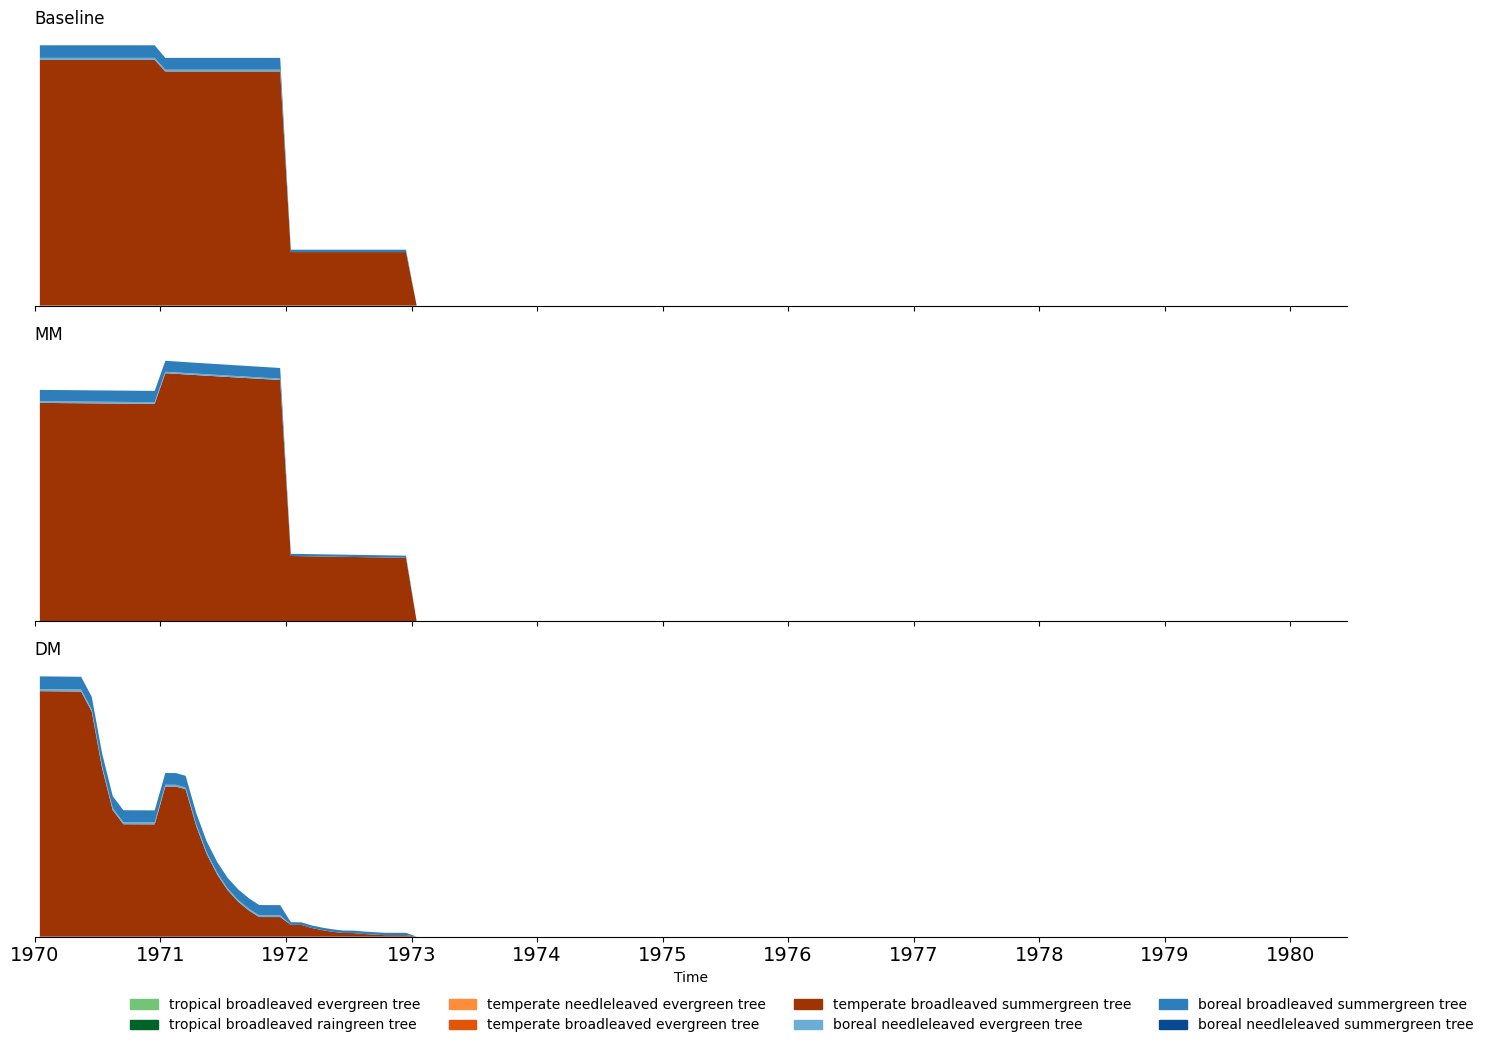

Saved figure to: /home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-116_40.png


In [2]:
plot_fpc_at_point(lon=-116, lat=40, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-116_40.png")



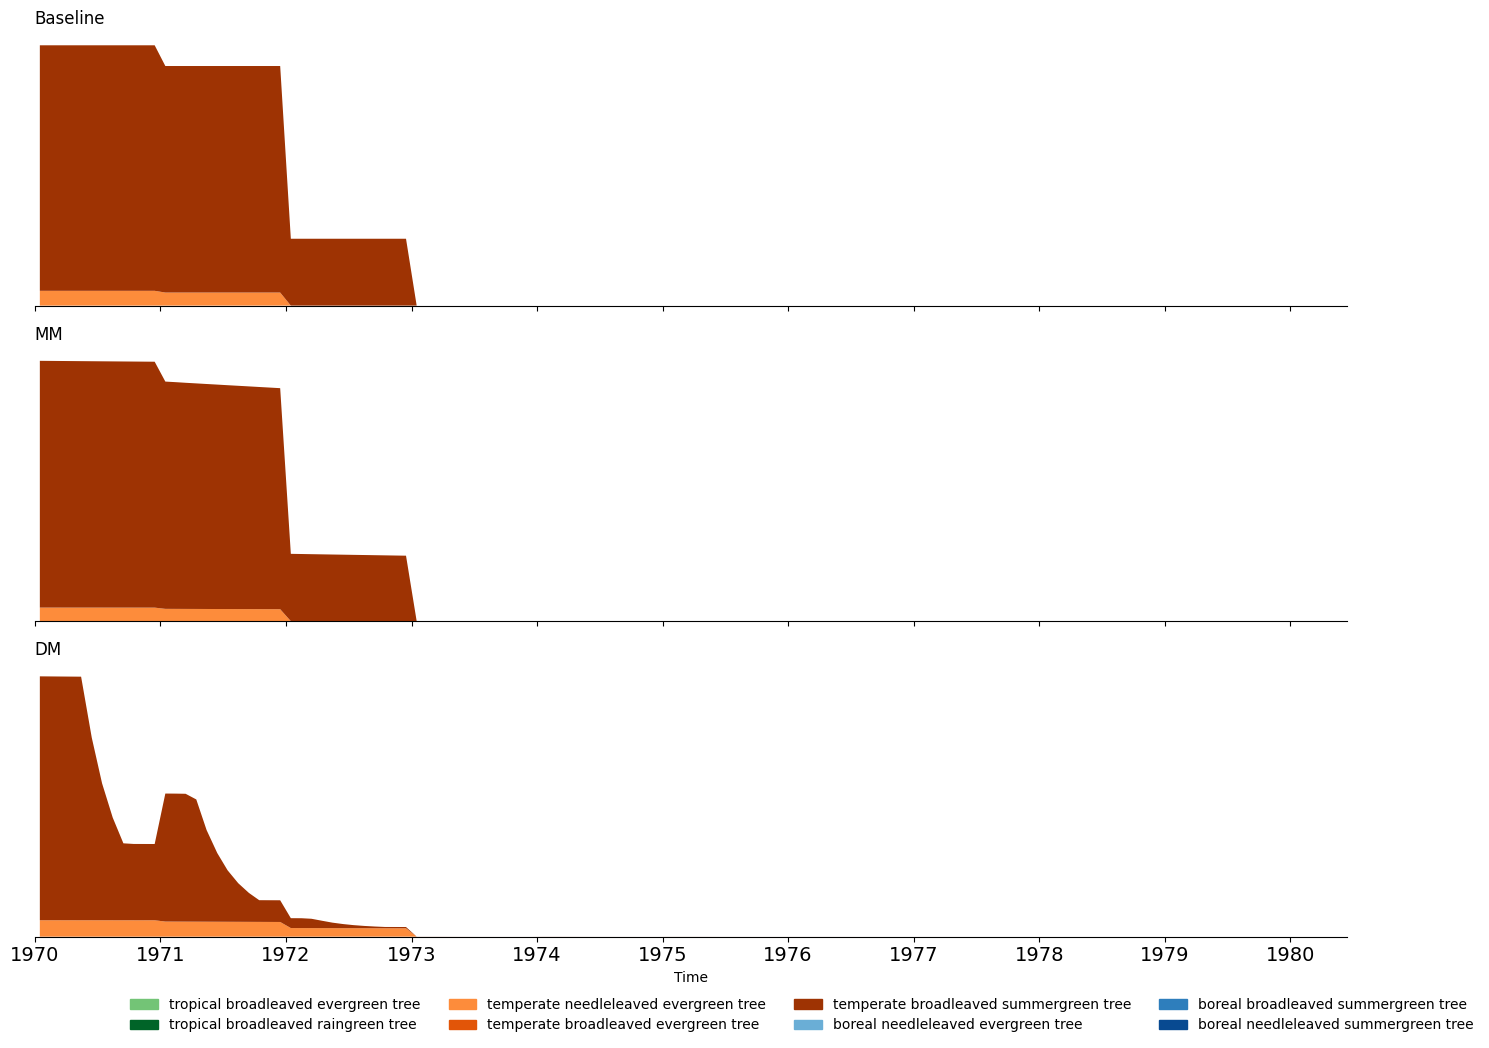

Saved figure to: /home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-122_41.png


In [4]:
plot_fpc_at_point(lon=-122.5, lat=41, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-122_41.png")



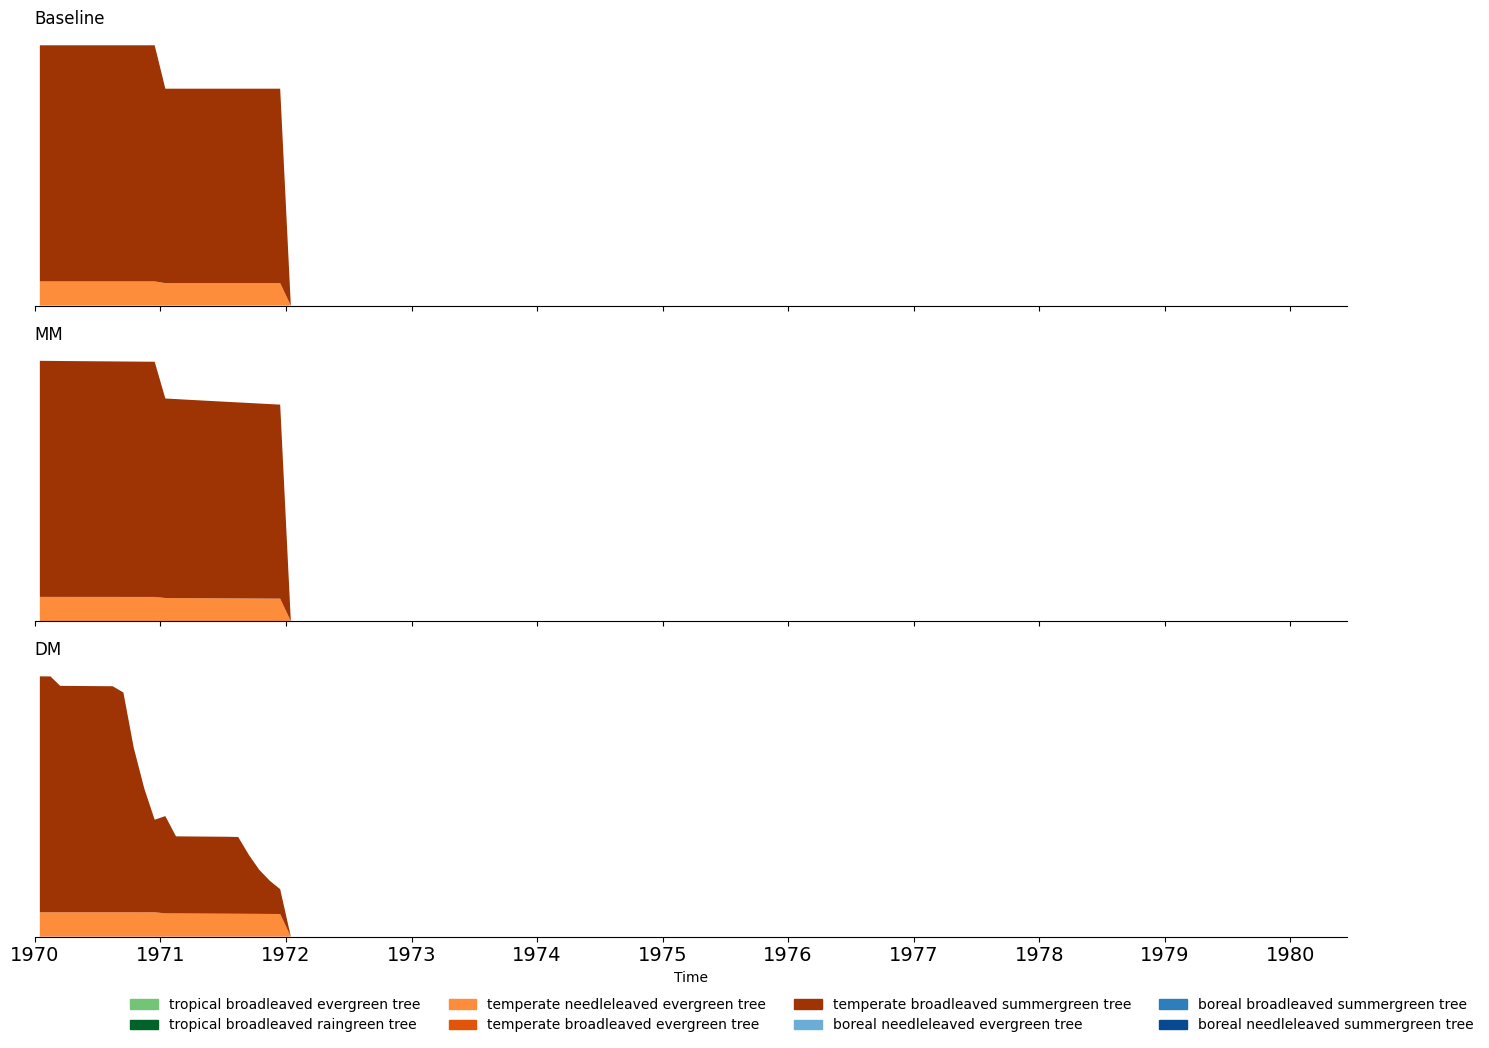

Saved figure to: /home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_148_-37.png


In [5]:
plot_fpc_at_point(lon=148, lat=-37, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_148_-37.png")


In [ ]:
# plot_fpc_at_point(lon=92, lat=26, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_92_26.png")


In [ ]:
# plot_fpc_at_point(lon=-61, lat=-36, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-61_-36.png")

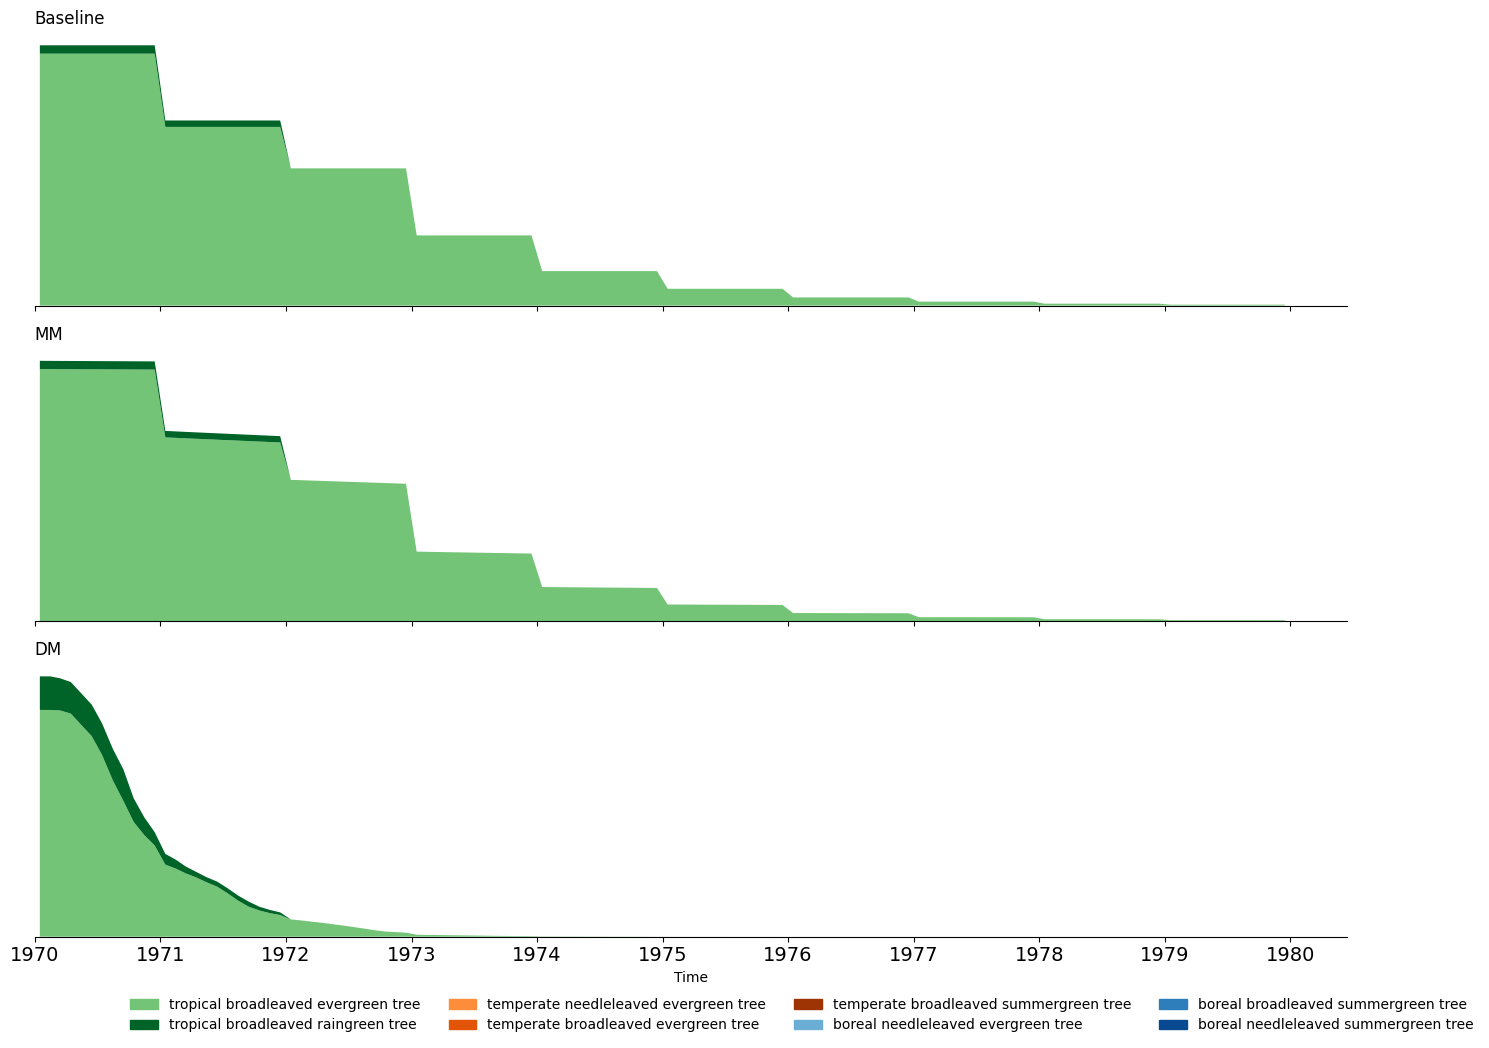

Saved figure to: /home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-55_-15.png


In [6]:
plot_fpc_at_point(lon = -55, lat = -15, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-55_-15.png")


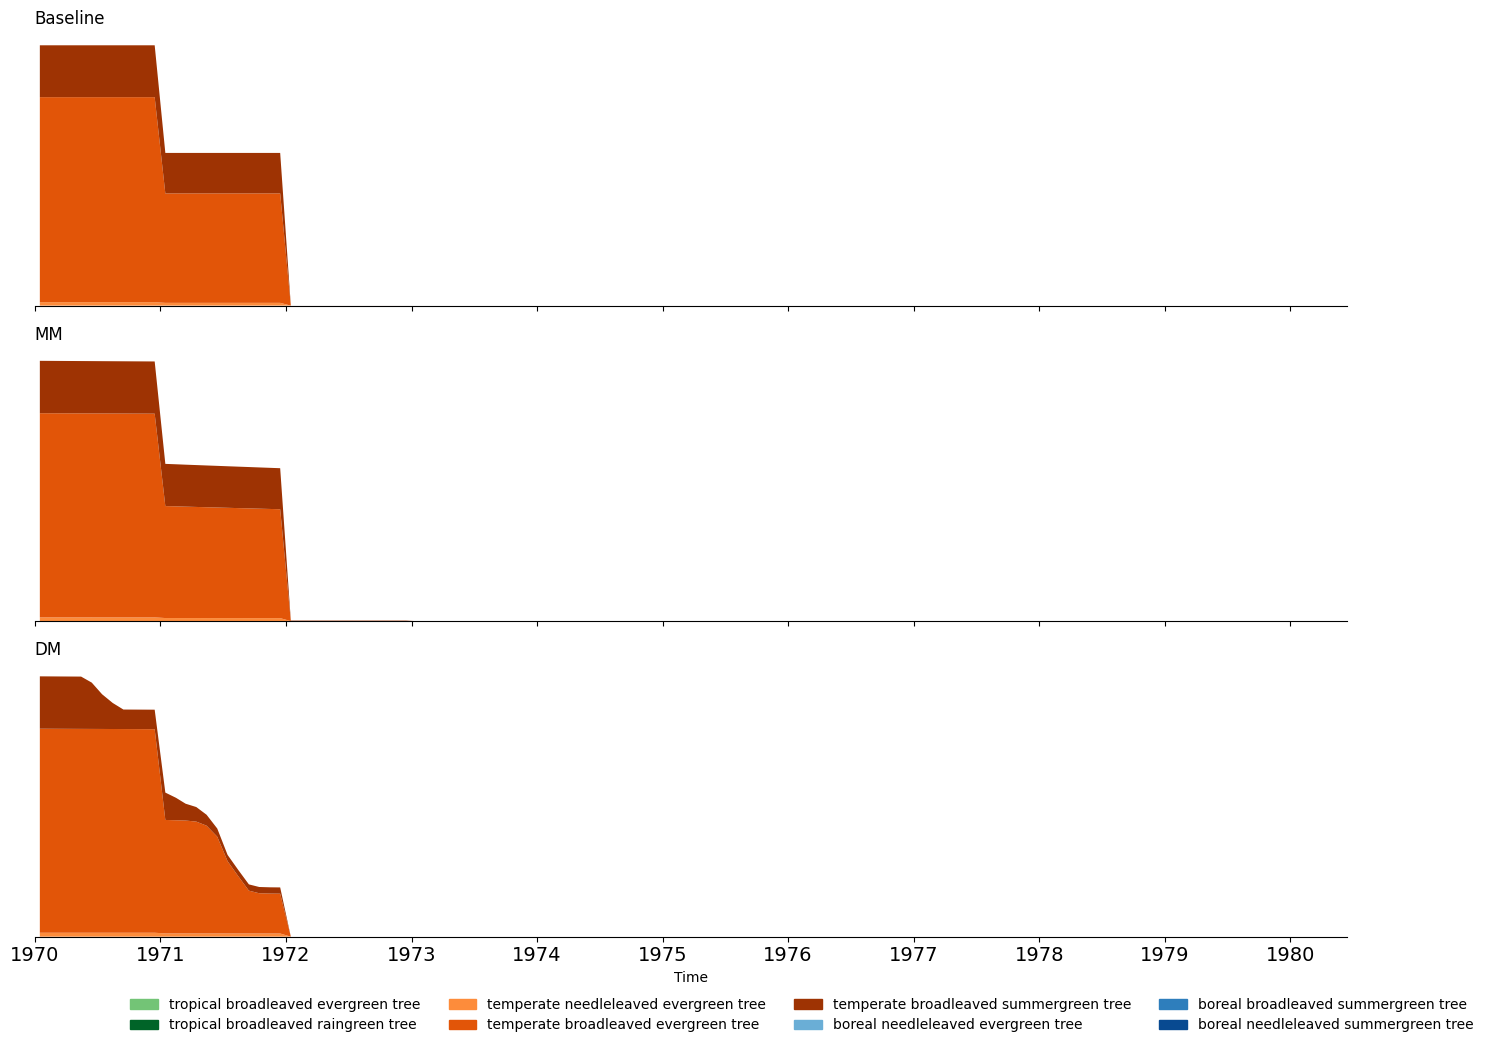

Saved figure to: /home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_112_25.png


In [7]:
plot_fpc_at_point(lon = 112.1, lat = 25.1, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_112_25.png")

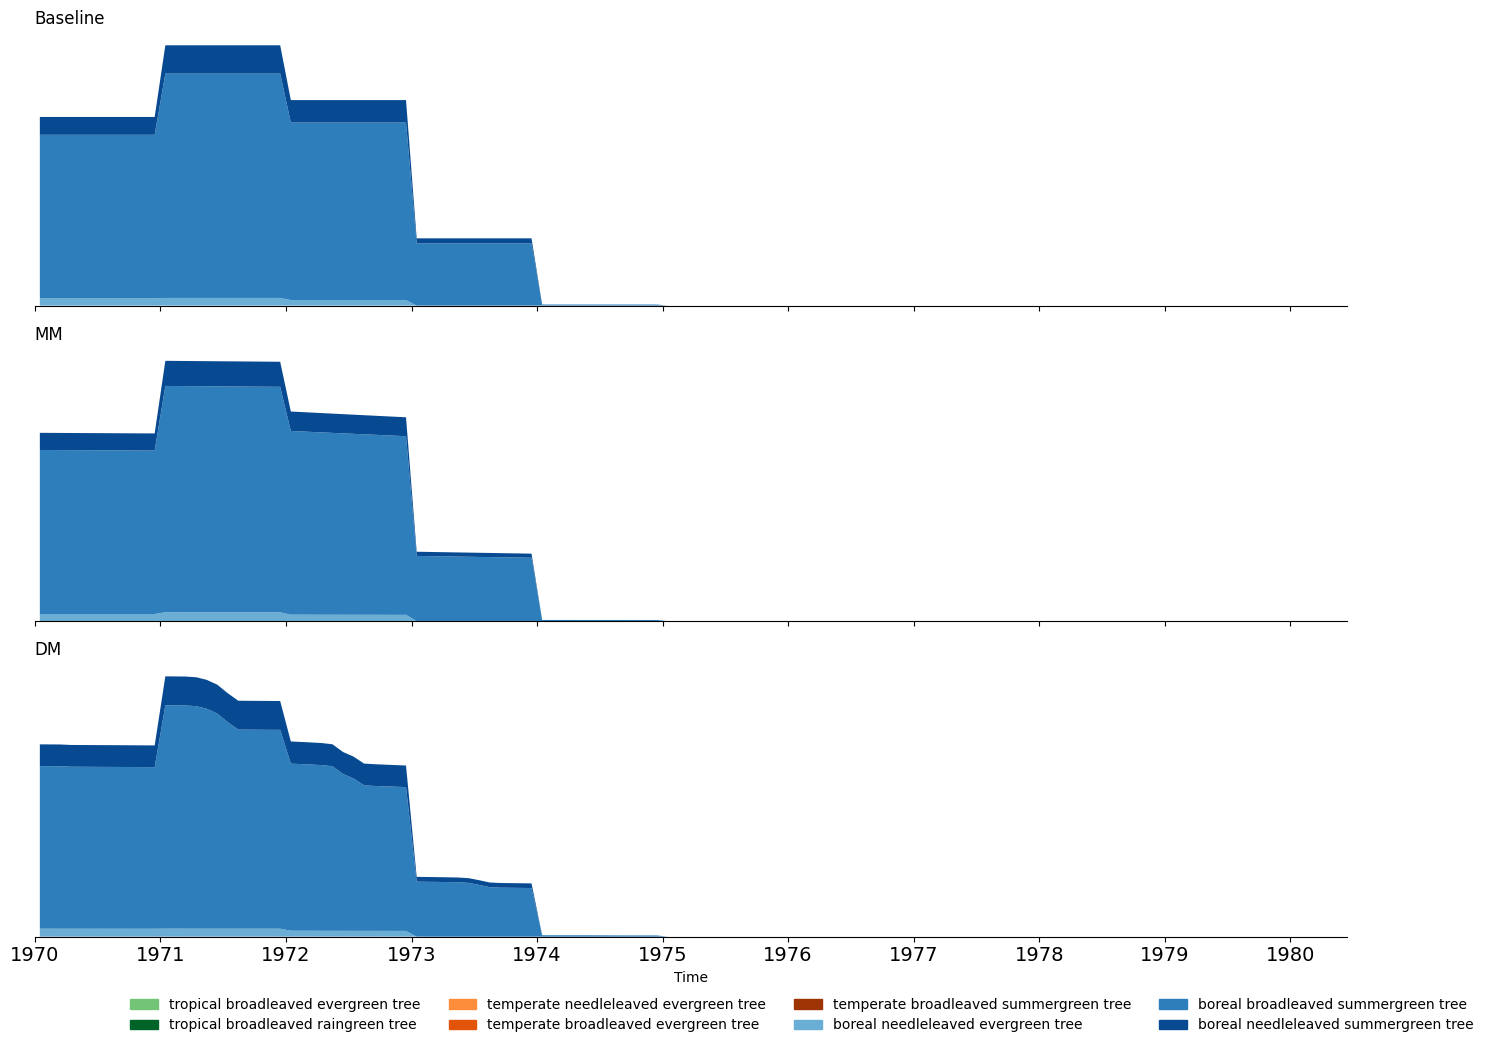

Saved figure to: /home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_86_60.png


In [8]:
plot_fpc_at_point(lon = 86, lat = 60, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_86_60.png")